In [1]:
# Import useful packages for galactic unresolved stellar population synthesis (SPS) modeling
import numpy as np
import matplotlib.pyplot as plt
import fsps
import pandas as pd

# Needed to export the directory so fsps knows where to look. I thought I only
# had to do this once when I intalled, but I need to do it every time. Gemini
# had me put it in my conda env config file because I didn't want to clutter my
# bashrc. First I activated the ay_250 env, then I ran conda env config vars set SPS_HOME="/path/"
# and then I had to reactivate the env but now it works
# export SPS_HOME="/mnt/c/Users/noahs/Desktop/Berkeley/Year 1/Semester 2/Stellar Pops/fsps"

In [2]:
# Load the galaxy spectra
galaxy_filename = "mystery_galaxy_sed.tsv"
galaxy_data = pd.read_csv(galaxy_filename, sep="\t")

In [3]:
# Put wavelength in the pandas dataframe, convert from frequency
c_m_s = 299792458
galaxy_data["Wavelength (m)"] = c_m_s / galaxy_data["Frequency (Hz)"]
galaxy_data["Wavelength (Angstrom)"] = galaxy_data["Wavelength (m)"] * 1e10
galaxy_data["Flux Density (Jy)"] = galaxy_data["Flux Density"]
galaxy_data["Flux Density (erg)"] = galaxy_data["Flux Density (Jy)"] * 1e-23
galaxy_data["FD Unc High (erg)"] = galaxy_data["FD Unc High"] * 1e-23
galaxy_data["FD Unc Low (erg)"] = galaxy_data["FD Unc Low"] * 1e-23

In [4]:
galaxy_data.head(5)

,Bandpass,Magnitude,Unc High,Unc Low,Unit,Frequency (Hz),Flux Density,FD Unc High,FD Unc Low,Flux,F Unc High,F Unc Low,Telescope,Wavelength (m),Wavelength (Angstrom),Flux Density (Jy),Flux Density (erg),FD Unc High (erg),FD Unc Low (erg)
0,FUV (GALEX) AB,13.83,0.01,0.01,mag,1.960000e+15,0.010670,0.000098,0.000098,2.091320e+13,1.925504e+11,1.925504e+11,GALEX,1.529553e-07,1529.553354,0.010670,1.067000e-25,9.824000e-28,9.824000e-28
1,NUV (GALEX) AB,14.12,0.01,0.01,mag,1.320000e+15,0.008166,0.000075,0.000075,1.077912e+13,9.927720e+10,9.927720e+10,GALEX,2.271155e-07,2271.155071,0.008166,8.166000e-26,7.521000e-28,7.521000e-28
2,u (SDSS) AB,13.37,0.05,0.05,mag,8.440000e+14,0.016290,0.000750,0.000750,1.374876e+13,6.329156e+11,6.329156e+11,2.5m,3.552043e-07,3552.043355,0.016290,1.629000e-25,7.499000e-27,7.499000e-27
3,g (SDSS) AB,11.98,0.05,0.05,mag,6.400000e+14,0.058470,0.002693,0.002693,3.742080e+13,1.723520e+12,1.723520e+12,2.5m,4.684257e-07,4684.257237,0.058470,5.847000e-25,2.693000e-26,2.693000e-26
4,r (SDSS) AB,11.88,0.05,0.05,mag,4.860000e+14,0.064120,0.002953,0.002953,3.116232e+13,1.435158e+12,1.435158e+12,2.5m,6.168569e-07,6168.568959,0.064120,6.412000e-25,2.953000e-26,2.953000e-26


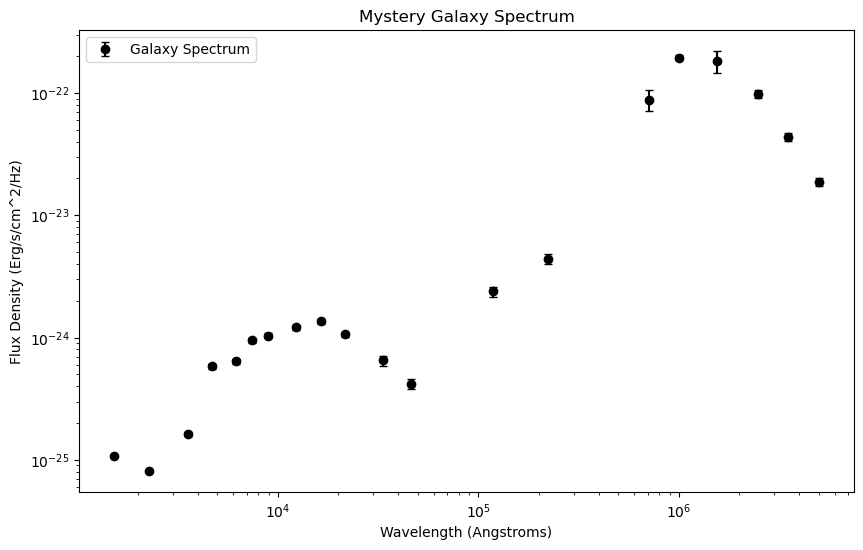

In [49]:
# Plot the galaxy flux density as a function of wavelength
plt.figure(figsize=(10, 6))
plt.errorbar(galaxy_data["Wavelength (Angstrom)"], galaxy_data["Flux Density (erg)"], yerr=[galaxy_data["FD Unc Low (erg)"], galaxy_data["FD Unc High (erg)"]], label="Galaxy Spectrum", fmt="o", capsize=3, ecolor='black', color='black')

# Labels
plt.xlabel("Wavelength (Angstroms)")
plt.ylabel("Flux Density (Erg/s/cm^2/Hz)")
plt.title("Mystery Galaxy Spectrum")
plt.legend()

# Scale axes logarithmically
plt.xscale('log')
plt.yscale('log')

# Show plot
plt.show()

In [55]:
# Function to plot the underlying data
# Returns the fig, ax objects so we can plot on top of it
def plot_data(title_label=""):
    # Plot the galaxy flux density as a function of wavelength
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(galaxy_data["Wavelength (Angstrom)"], galaxy_data["Flux Density (erg)"], yerr=[galaxy_data["FD Unc Low (erg)"], galaxy_data["FD Unc High (erg)"]], label="Galaxy Spectrum", fmt="o", capsize=3, ecolor='black', color='black')

    # Labels
    ax.set_xlabel("Wavelength (Angstroms)")
    ax.set_ylabel("Flux Density (Erg/s/cm^2/Angstrom)")
    ax.set_title(f"Mystery Galaxy Spectrum\n{title_label}")

    # Scale axes logarithmically
    ax.set_xscale('log')
    ax.set_yscale('log')

    return fig, ax


# Make a function to plot a model underneath the data
# Model is a list of tuples of (wavelengths, flux densities in angstrom and erg/s/cm^2/Angstrom)
# Label is a string to label the model in the legend
def plot_model(models, labels=None, title_label=""):
    # Check inputs
    if type(models) is not list and type(models) is not type(np.array([1])):
        models = [models]
        print(f"type models wrong: {type(models)}")
    if type(labels) is not list and type(np.array([1])):
        labels = [labels]
        print(f"Type labels wrong: {type(labels)}")
    assert(len(models) == len(labels)), "Labels must be the same length as models"

    # Plot the measured data
    fig, ax = plot_data(title_label=title_label)

    # Plot model(s)
    for i, model in enumerate(models):
        # Unpack data
        wavelengths, flux_densities = model 
        label = labels[i]

        # Cut to the same wavelength range as the data
        mask = (wavelengths >= galaxy_data["Wavelength (Angstrom)"].min()) & (wavelengths <= galaxy_data["Wavelength (Angstrom)"].max())
        wavelengths = wavelengths[mask]
        flux_densities = flux_densities[mask]

        # Plot model
        ax.plot(wavelengths, flux_densities, label=label, marker='.')
    
    plt.legend()
    return fig, ax


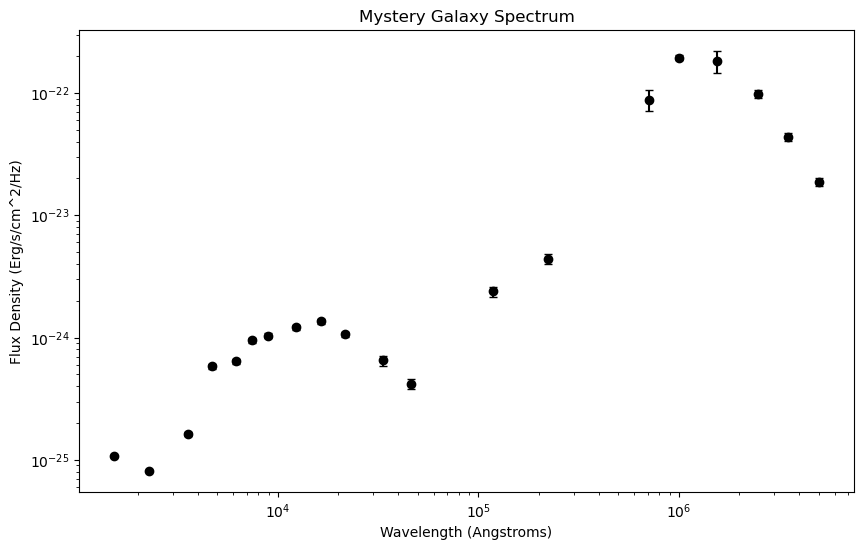

In [47]:
fig, ax = plot_data()
plt.show()

In [ ]:


# Want to find stellar mass, metallicity, dust content, & star formation rate
# that best matches the observed spectrum. We can use the FSPS python package to generate
# model spectra for different combinations of these parameters and compare them to the observed spectrum.

In [ ]:
# Let's generate a model spectrum using fsps with some initial parameters and 
# plot it on top of the data to see how it looks. We can then adjust the 
# parameters to try to get a better fit to the data.


In [50]:
# Model_luminosity is the luminosity of the model spectrum in L_sun/Hz. We can get this from fsps.
# We want to convert this to the observed flux density in erg/s/cm^2/Hz using the distance to the galaxy.
# Note also that the luminosity is scaled such that the galaxy has a mass of 1 solar mass, 
# so we will need to multiply by the stellar mass of the galaxy to get the total luminosity.
def observed_flux(model_luminosity_density, M_formed):
    # Add distance
    dist_mpc = 20
    dist_pc = dist_mpc * 1e6
    dist_cm = dist_pc * 3.086e18
    
    # Convert from L_sun/Hz to erg/s/Hz
    model_luminosity_density_erg = model_luminosity_density * 3.828e33

    # Convert luminosity from erg/s/Hz to erg/s/cm^2/Hz
    flux_density_cgs = (model_luminosity_density_erg/ (4 * np.pi * (dist_cm)**2))

    # Scale by the stellar mass of the galaxy
    scaled_flux_density_cgs = flux_density_cgs * M_formed
    
    return scaled_flux_density_cgs

In [51]:
# Do an example generation using code from my pedagogical spectrum to see what
# the fit looks like - we can change from there
# This generates a spectrum for a galaxy with a delayed-tau model of SFH
# and various dust content, solar metallicity, and an age of 5 Gyr. 
# We can adjust these parameters to see how the fit changes.
sp = fsps.StellarPopulation(zcontinuous=1, logzsol=0.0, 
                            sfh=4, tau=1.0, 
                            dust_type=2,
                            add_neb_emission=True, 
                            add_dust_emission=True)

# dust_depths = [0.0, 0.5, 2.0, 5.0, 10.0]
dust_depths = [0.0, 2.0, 5.0]
age = 5.0

# Store results in a dictionary: {dust_value: spectrum_array}
sed_data = {}
# peraa=False gives L_sun/hz not L_sun/Angstrom
wave, _ = sp.get_spectrum(tage=age, peraa=False) # Get wavelength grid once

for d in dust_depths:
    sp.params['dust2'] = d
    _, spec = sp.get_spectrum(tage=age, peraa=False) # Get spectrum in L_sun/Hz
    sed_data[d] = spec.copy() # Store a copy of the spectrum

In [52]:
# Convert models to observed flux density
model_flux_density = {}
M_formed = 1e10 # Solar masses of the galaxy
for d in dust_depths:
    model_flux_density[d] = observed_flux(sed_data[d], M_formed)

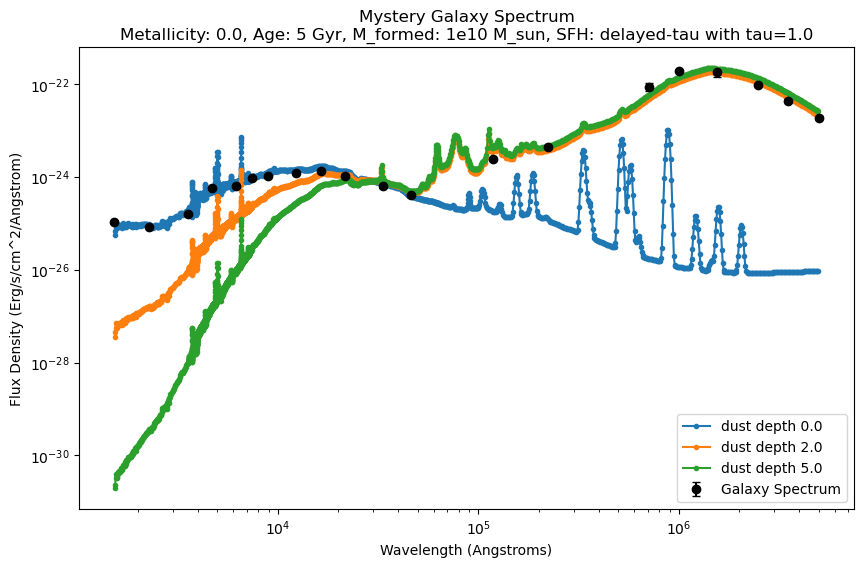

In [56]:
models = [(wave, model_flux_density[0.0]), (wave, model_flux_density[2.0]), (wave, model_flux_density[5.0])]
labels = ["dust depth 0.0", "dust depth 2.0", "dust depth 5.0"]
fig, ax = plot_model(models, labels, title_label="Metallicity: 0.0, Age: 5 Gyr, M_formed: 1e10 M_sun, SFH: delayed-tau with tau=1.0")
plt.show()

In [ ]:
# Looks like a dust depth of ~2 matches pretty well at IR wavelengths but
# a dust depth of ~0 matches well at UV wavelengths
# This suggests that the galaxy has some dust, but not too much. We can try adjusting the age and metallicity to see if we can get a better fit to the UV and IR simultaneously.

In [61]:
# Dan gave the hint to use a constant SFH. Let's try that
metallicity = 0.2
sp = fsps.StellarPopulation(zcontinuous=1, logzsol=metallicity, 
                            sfh=1,
                            dust_type=2,
                            add_neb_emission=True, 
                            add_dust_emission=True)

# We have UV emission, so our dust is probably not too high
dust_depth = 0.1
sp.params['dust2'] = dust_depth
age = 10 # Gyr

# peraa=False gives L_sun/hz not L_sun/Angstrom
wave, spec = sp.get_spectrum(tage=age, peraa=False)

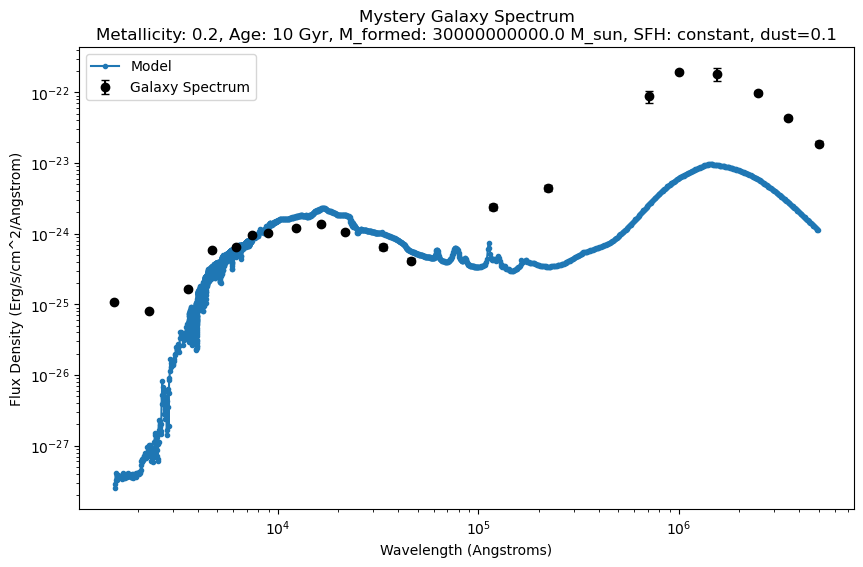

In [62]:
# Convert models to observed flux density
M_formed = 3e10 # Solar masses of the galaxy
model_flux_density = observed_flux(spec, M_formed)

models = [(wave, model_flux_density)]
labels = ["Model"]
fig, ax = plot_model(models, labels, title_label=f"Metallicity: {metallicity}, Age: {age} Gyr, M_formed: {M_formed} M_sun, SFH: constant, dust={dust_depth}")
plt.show()